<a href="https://colab.research.google.com/github/kanish-27/KanishKrishna-Codeboosters-Internship-2026/blob/main/Day_02_Database_SQL_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
print("All libraries imported successfully!")
print(f"panfdas version:{pd.__version__}")
print(f"sqlite3 version:{sqlite3.version}")

All libraries imported successfully!
panfdas version:2.2.2
sqlite3 version:2.6.0


In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
df=pd.read_csv("/content/student_performance.csv")
print(f"Dataset loaded:{df.shape[0]} students,{df.shape[1]} columns")
print(f"Columns:{df.columns.tolist()}")
print("\nFirst 3 rows:")
df.head(3)

Dataset loaded:30 students,13 columns
Columns:['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']

First 3 rows:


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


In [26]:
conn=sqlite3.connect('college.db')
cursor=conn.cursor()
df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)
cursor.execute("SELECT COUNT(*) FROM students")
count=cursor.fetchone()[0]
print(f"Database 'college.db' created successfully!")
print(f"Table 'students' has {count} rows")

Database 'college.db' created successfully!
Table 'students' has 30 rows


In [27]:
#PRAGMA is a special SQLite command (not standard SQL)
#table_info() shows the structure of the table
cursor.execute("PRAGMA table_info(students)")
columns_info=cursor.fetchall()
#fetchall() retriews all result rows
print("Table structure of 'students':")
#<25 means left-align 25 characters(for neat formatting)
print(f"{'Column Name':<25}{'Data Type':<12}")
print("-"*38)
for col in columns_info:
  print(f"{col[1]:<25}{col[2]:<12}")
#col[1]=column name,col[2]=data type

Table structure of 'students':
Column Name              Data Type   
--------------------------------------
student_id               INTEGER     
name                     TEXT        
age                      INTEGER     
gender                   TEXT        
department               TEXT        
semester                 INTEGER     
math_score               INTEGER     
science_score            INTEGER     
english_score            INTEGER     
programming_score        INTEGER     
attendance_percentage    INTEGER     
city                     TEXT        
admission_year           INTEGER     


In [28]:
def run_query(sql, description=""):
  """
  Runs a SQL query and returns result as a Pandas DataFrame

  Parameters:
  -------------
  sql          :str - SQL query string to execute
  description  :str - A label to print above the results

  Returns:
  ----------
   Pandas DataFrame containing the query results
  """
  if description:
    print(f"\n{'='*55}")
    print(f"{description}")
    print(f"{'=*55'}")

  result=pd.read_sql_query(sql, conn)
  # 1.Executes the SQL query against the database(conn)
  # 2.Converts the result into Pandas DataFrame
  print(result.to_string(index=False))
  return result

In [33]:
query1="""
SELECT student_id,name,department,math_score,attendance_percentage
FROM students
LIMIT 10
"""
result1=run_query(query1,"Query 1:First 10 Studnets (SELECT + LIMIT)")


Query 1:First 10 Studnets (SELECT + LIMIT)
=*55
 student_id         name       department  math_score  attendance_percentage
       1001 Aarav Sharma Computer Science          85                     92
       1002  Priya Patel Computer Science          76                     87
       1003  Rohit Verma      Electronics          65                     78
       1004  Sneha Reddy       Mechanical          70                     95
       1005   Arjun Nair Computer Science          92                     90
       1006  Meera Joshi      Electronics          58                     72
       1007  Kiran Kumar            Civil          73                     85
       1008  Divya Singh Computer Science          88                     96
       1009 Rahul Mishra       Mechanical          62                     68
       1010   Ananya Das Computer Science          95                     98


In [35]:
query2="""
SELECT name,department,math_score
FROM students
ORDER BY math_score DESC
LIMIT 10
"""
result2=run_query(query2,"Query 2:Top 10 Students (ORDER BY + LIMIT)")


Query 2:Top 10 Students (ORDER BY + LIMIT)
=*55
          name       department  math_score
    Ananya Das Computer Science          95
   Tanvi Mehta Computer Science          93
    Arjun Nair Computer Science          92
Akanksha Yadav Computer Science          91
Swati Kulkarni Computer Science          90
   Divya Singh Computer Science          88
  Ritu Agarwal      Electronics          87
     Amit Bose Computer Science          86
  Aarav Sharma Computer Science          85
 Gaurav Shukla Computer Science          84


In [37]:
query3="""
SELECT name,math_score,science_score,programming_score,attendance_percentage
FROM students
WHERE department='Computer Science'
ORDER BY programming_score DESC
"""
res3=run_query(query3,"Query 3:Computer Science Students (WHERE filter)")
print(f"\nTotal cs studnets found:{len(res3)}")


Query 3:Computer Science Students (WHERE filter)
=*55
          name  math_score  science_score  programming_score  attendance_percentage
    Ananya Das          95             89                 97                     98
   Tanvi Mehta          93             90                 96                     97
    Arjun Nair          92             88                 95                     90
Akanksha Yadav          91             93                 94                     95
   Divya Singh          88             91                 93                     96
Swati Kulkarni          90             87                 92                     94
  Aarav Sharma          85             78                 91                     92
     Amit Bose          86             82                 89                     91
    Suresh Rao          83             86                 88                     88
 Gaurav Shukla          84             79                 87                     87
  Nisha Kapoor       

In [38]:
query4="""
SELECT name,department,attendance_percentage
FROM students
WHERE attendance_percentage>90
AND department != 'Civil'
ORDER BY attendance_percentage DESC
"""
res4=run_query(query4)

          name       department  attendance_percentage
    Ananya Das Computer Science                     98
   Tanvi Mehta Computer Science                     97
   Divya Singh Computer Science                     96
   Sneha Reddy       Mechanical                     95
Akanksha Yadav Computer Science                     95
Swati Kulkarni Computer Science                     94
  Ritu Agarwal      Electronics                     93
  Aarav Sharma Computer Science                     92
 Kavya Nambiar       Mechanical                     91
     Amit Bose Computer Science                     91


In [40]:
query5="""
SELECT
department,
COUNT(*) AS num_students,
ROUND(AVG(math_score),2) AS avg_math,
ROUND(AVG(science_score),2) AS avg_science,
ROUND(AVG(programming_score),2) AS avg_programming,
ROUND(AVG(attendance_percentage),2) AS avg_attendance
FROM students
GROUP BY department
ORDER BY num_students DESC
"""
res5=run_query(query5)

      department  num_students  avg_math  avg_science  avg_programming  avg_attendance
Computer Science            13     85.62        84.46            89.23           90.69
      Mechanical             6     71.00        76.50            49.33           83.50
     Electronics             6     71.00        74.17            61.50           80.33
           Civil             5     63.40        66.60            40.60           74.60


In [41]:
query6="""
SELECT
department,
ROUND(AVG(math_score),2) AS avg_math,
COUNT(*) AS students
FROM students
GROUP BY department
HAVING AVG(math_score)>70
ORDER BY avg_math DESC
"""
res6=run_query(query6)

      department  avg_math  students
Computer Science     85.62        13
      Mechanical     71.00         6
     Electronics     71.00         6


In [43]:
query7="""
SELECT
gender,
COUNT(*) AS num_students,
ROUND(AVG(math_score),2) AS avg_math,
ROUND(AVG(programming_score),2) AS avg_programming,
ROUND(AVG(attendance_percentage),2) AS avg_attendance
FROM students
GROUP BY gender
"""
res7=run_query(query7)

gender  num_students  avg_math  avg_programming  avg_attendance
Female            15     78.47             70.2           88.53
  Male            15     73.67             65.0           80.47


In [44]:
query8="""
SELECT
name,
department,
math_score+science_score+english_score+programming_score AS total_score,
attendance_percentage
FROM students
ORDER BY total_score DESC
LIMIT 10
"""
res8=run_query(query8)

          name       department  total_score  attendance_percentage
    Ananya Das Computer Science          371                     98
   Tanvi Mehta Computer Science          367                     97
Akanksha Yadav Computer Science          365                     95
    Arjun Nair Computer Science          356                     90
   Divya Singh Computer Science          356                     96
Swati Kulkarni Computer Science          354                     94
     Amit Bose Computer Science          336                     91
    Suresh Rao Computer Science          334                     88
  Nisha Kapoor Computer Science          327                     89
  Aarav Sharma Computer Science          326                     92


In [49]:
dept_data={
    'dept_code':['CS','EC','ME','CE'],
    'dept_name':['Computer Science','Electronics','Mechanical','Civil'],
    'hod_name':['Dr.Sharma','Dr.Reddy','Dr.Patel','Dr.Kumar'],
    'established':[1985,1988,1972,1965],
    'intake': [60,60,60,60]
}
dept_df=pd.DataFrame(dept_data)
dept_df.to_sql('departments',conn,if_exists='replace',index=False)
print("Created 'departments' table:")
print(dept_df.to_string(index=False))
dept_map={
    'Computer Science':'CS',
    'Electronics':'EC',
    'Mechanical':'ME',
    'Civil':'CE'
}
df['dept_code']=df['department'].map(dept_map)
df.to_sql('students',conn,if_exists='replace',index=False)
print("Created 'departments' table:")
print(dept_df.to_string(index=False))
query_join="""
SELECT
s.name,
s.math_score,
d.dept_name,
d.hod_name,
d.established
FROM students AS s
INNER JOIN departments AS d
ON s.dept_code=d.dept_code
ORDER BY s.math_score DESC
LIMIT 8
"""
result_join=run_query(query_join,"JOIN: Students with Department Details (INNER JOIN)")

Created 'departments' table:
dept_code        dept_name  hod_name  established  intake
       CS Computer Science Dr.Sharma         1985      60
       EC      Electronics  Dr.Reddy         1988      60
       ME       Mechanical  Dr.Patel         1972      60
       CE            Civil  Dr.Kumar         1965      60
Created 'departments' table:
dept_code        dept_name  hod_name  established  intake
       CS Computer Science Dr.Sharma         1985      60
       EC      Electronics  Dr.Reddy         1988      60
       ME       Mechanical  Dr.Patel         1972      60
       CE            Civil  Dr.Kumar         1965      60

JOIN: Students with Department Details (INNER JOIN)
=*55
          name  math_score        dept_name  hod_name  established
    Ananya Das          95 Computer Science Dr.Sharma         1985
   Tanvi Mehta          93 Computer Science Dr.Sharma         1985
    Arjun Nair          92 Computer Science Dr.Sharma         1985
Akanksha Yadav          91 Computer 

# Step 1: Get data using SQL

chart1_sql = """

SELECT department, ROUND (AVG(math_score), 2) AS avg_math
FROM students

GROUP BY department

ORDER BY avg_math DESC
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)
# pd.read sql query runs the SQL and returns a DataFrame
# chart1_data has two columns: 'department' and 'avg_math'

# Step 2: Create the bar chart

fig, ax = plt.subplots(figsize=(10, 6))

# fig = the whole figure (canvas)

# ax = the axes object (the actual plot area)

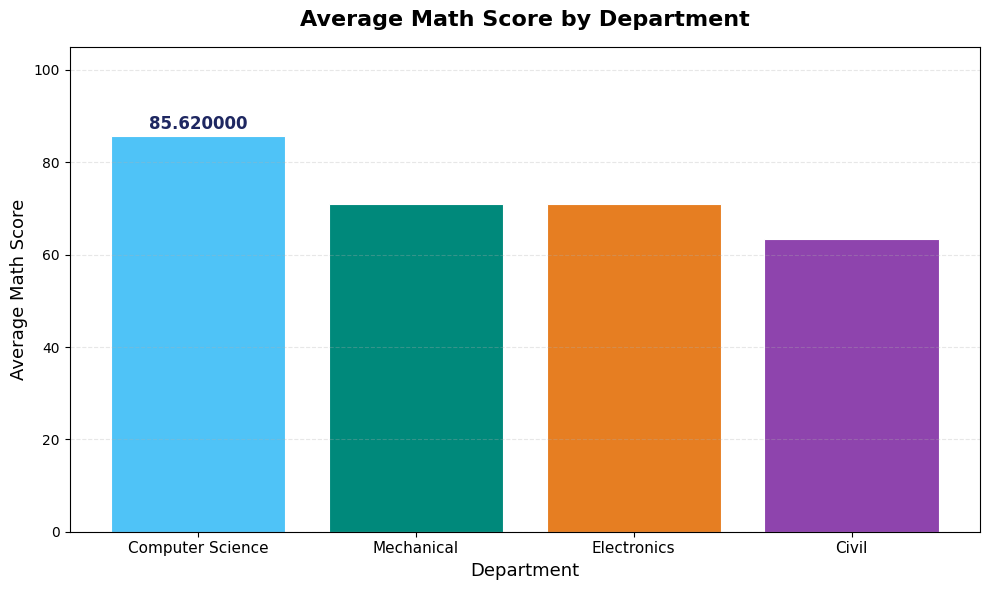

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [52]:
chart1_sql="""
SELECT department,ROUND(AVG(math_score),2) AS avg_math
FROM students
GROUP BY department
ORDER BY avg_math DESC
"""
chart1_data=pd.read_sql_query(chart1_sql,conn)
fig,ax=plt.subplots(figsize=(10,6))
bar_colours=['#4FC3F7','#00897B','#E67E22','#8E44AD']
bars=ax.bar(
    chart1_data['department'],
    chart1_data['avg_math'],
    color=bar_colours,
    edgecolor='white',
    linewidth=0.8
)
for bar in bars:
  height=bar.get_height()
  ax.text(
      bar.get_x()+bar.get_width()/2,
      height+0.8,
      f'{height:1f}',
      ha='center',va='bottom',
      fontsize=12,fontweight='bold',
      color='#1E2761'
  )
  ax.set_title('Average Math Score by Department',fontsize=16,fontweight='bold',pad=15)
  ax.set_xlabel('Department',fontsize=13)
  ax.set_ylabel('Average Math Score',fontsize=13)
  ax.set_ylim(0,105)
  ax.tick_params(axis='x',labelsize=11)
  ax.grid(axis='y',alpha=0.3,linestyle='--')
  plt.tight_layout()
  plt.show()


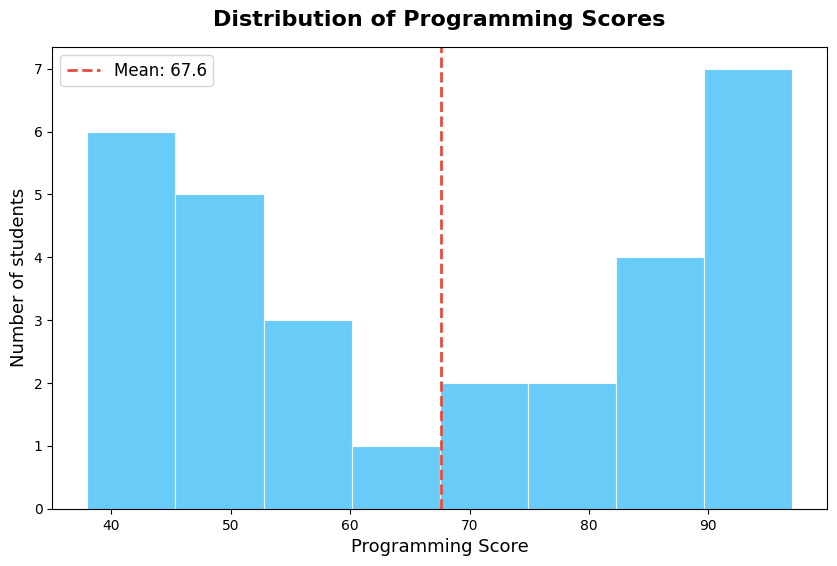

In [54]:
prog_scores=df['programming_score'].tolist()
fig,ax=plt.subplots(figsize=(10,6))
n,bins,patches=ax.hist(
    prog_scores,
    bins=8,
    color='#4FC3F7',
    edgecolor='white',
    linewidth=0.8,
    alpha=0.85
)
mean_score=sum(prog_scores)/len(prog_scores)
ax.axvline(
    x=mean_score,
    color='#E74C3C',
    linestyle='--',
    linewidth=2,
    label=f'Mean: {mean_score:.1f}'
)
ax.set_title('Distribution of Programming Scores',fontsize=16,fontweight='bold',pad=15)
ax.set_xlabel('Programming Score',fontsize=13)
ax.set_ylabel('Number of students',fontsize=13)
ax.legend(fontsize=12)
plt.show()

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
df=pd.DataFrame({
    'Category':np.random.choice(['A','B','C'],size=100),
    'Value':np.random.randint(10,100,100),
    'Score':np.random.randint(1,10,100)
})
df.head()

,Category,Value,Score
0,B,35,1
1,B,56,1
2,B,10,2
3,A,54,1
4,A,44,7


In [59]:
import plotly.express as px
category_counts=df['Category'].value_counts().reset_index()
category_counts.columns=['Category', 'Score']
fig=px.bar(
category_counts,
x='Category',
y='Score',
color='Category',
title='Interactive Category Distribution',
text='Score'
)
fig.update_traces(textposition='outside')
fig.update_layout(xaxis_title="Category",yaxis_title="Count")
fig.show()